# TD2 — Reconnaissance d'expressions faciales
## LBP + KNN sur FER-2013
**Auteur :** Walid BELABEDDOU  
**Date :** Avril 2026  
**Cours :** Interface Homme Machine — National University of Science and Technology POLITEHNICA Bucharest

## Plan du notebook

1. [Introduction](#introduction)
2. [Importation des librairies](#importation-des-librairies)
3. [Chargement des données](#chargement-des-données)
4. [Extraction des features LBP](#extraction-des-features-lbp)
5. [Entraînement du modèle KNN](#entraînement-du-modèle-knn)
6. [Évaluation du modèle](#évaluation-du-modèle)
7. [Matrice de confusion](#matrice-de-confusion)
8. [Visualisation des prédictions](#visualisation-des-prédictions)
9. [Conclusion](#conclusion)

## 1. Introduction
Dans ce TD, nous implémentons un système de reconnaissance 
d'expressions faciales en utilisant deux techniques :
- **LBP (Local Binary Patterns)** : pour extraire les features
- **KNN (K-Nearest Neighbors)** : pour classifier les émotions

Le dataset utilisé est FER-2013 qui contient 35 000 images 
de visages en niveaux de gris (48×48 pixels) réparties en 
7 émotions : angry, disgust, fear, happy, neutral, sad, surprise.

## 2. Importation des librairies

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

## 3. Chargement des données
On charge les images depuis les dossiers train et test.
Chaque image est convertie en tableau numpy de 48×48 valeurs.

In [3]:
TRAIN_DIR = r"C:\Users\innova\Documents\MASTER 1\INTERFACE HOMME MACHINE\TD02\archive\train"
TEST_DIR  = r"C:\Users\innova\Documents\MASTER 1\INTERFACE HOMME MACHINE\TD02\archive\test"

EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print("Dossier train :", os.path.exists(TRAIN_DIR))
print("Dossier test  :", os.path.exists(TEST_DIR))

Dossier train : True
Dossier test  : True


In [4]:
def load_images(folder):
    images = []
    labels = []
    for label, emotion in enumerate(EMOTIONS):
        emotion_path = os.path.join(folder, emotion)
        for filename in os.listdir(emotion_path):
            if filename.endswith('.jpg') or filename.endswith('.png'):
                img_path = os.path.join(emotion_path, filename)
                img = Image.open(img_path).convert('L')  # convertir en niveaux de gris garantit qu'elle est en niveaux de gris
                img = np.array(img)
                images.append(img)
                labels.append(label)
    return np.array(images), np.array(labels)

print("Chargement des images train...")
X_train, y_train = load_images(TRAIN_DIR)

print("Chargement des images test...")
X_test, y_test = load_images(TEST_DIR)

print(f"Train : {X_train.shape[0]} images")
print(f"Test  : {X_test.shape[0]} images")

Chargement des images train...
Chargement des images test...
Train : 28709 images
Test  : 7178 images


## 4. Extraction des features LBP
Le LBP transforme chaque pixel en un code entre 0 et 255 
en comparant ses 8 voisins. On divise ensuite l'image en 
16 blocs et on calcule l'histogramme de chaque bloc.
Résultat : un vecteur de 4096 valeurs par image.

In [5]:
def extract_lbp_features(images):
    features = []
    
    # Paramètres LBP
    radius = 1      # rayon = 1 pixel autour du centre
    n_points = 8    # 8 voisins
    n_blocks = 4    # grille 4×4 = 16 blocs
    
    for img in images:
        # Étape A : transformer chaque pixel en code LBP
        lbp_image = local_binary_pattern(img, n_points, radius, method='default')
        
        # Étape B : diviser en 16 blocs et calculer l'histogramme de chaque bloc
        block_size = img.shape[0] // n_blocks  # 48 // 4 = 12
        histogram = []
        
        for i in range(n_blocks):
            for j in range(n_blocks):
                # extraire le bloc
                block = lbp_image[i*block_size:(i+1)*block_size, 
                                  j*block_size:(j+1)*block_size]
                # calculer l'histogramme du bloc
                hist, _ = np.histogram(block, bins=256, range=(0, 256))
                # normaliser
                hist = hist / hist.sum()
                histogram.extend(hist)
        
        features.append(histogram)
    
    return np.array(features)

print("Extraction LBP train...")
X_train_lbp = extract_lbp_features(X_train)

print("Extraction LBP test...")
X_test_lbp = extract_lbp_features(X_test)

print(f"Forme des features train : {X_train_lbp.shape}")
print(f"Forme des features test  : {X_test_lbp.shape}")

Extraction LBP train...
Extraction LBP test...
Forme des features train : (28709, 4096)
Forme des features test  : (7178, 4096)


## 5. Entraînement du modèle KNN
Le KNN mémorise les 28 709 cartes d'identité avec leurs labels.
Il n'apprend rien — il stocke simplement tout.

In [10]:
# On crée le modèle KNN avec K=5 voisins
# weights='distance' : les voisins plus proches ont plus d'influence
# n_jobs=1 : utilise 1 seul processeur (évite un warning sur Windows)
knn = KNeighborsClassifier(n_neighbors=5, 
                           weights='distance', 
                           n_jobs=1)

# Phase d'entrainement : le KNN mémorise les 28709 cartes d'identité
# avec leurs labels correspondants
print("Entrainement du KNN...")
knn.fit(X_train_lbp, y_train)
print("Entrainement terminé !")

Entrainement du KNN...
Entrainement terminé !


## 6. Évaluation du modèle
On prédit les émotions sur les 7 178 images de test et on 
mesure l'accuracy globale ainsi que les performances par émotion.

In [11]:
# Prédiction sur les images de test
# Le KNN calcule la distance entre chaque image test
# et les 28709 images mémorisées, puis vote
print("Prédiction en cours...")
y_pred = knn.predict(X_test_lbp)
print("Prédiction terminée !")

# Accuracy globale
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {accuracy*100:.2f}%")

# Résultats détaillés par émotion
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=EMOTIONS))

Prédiction en cours...
Prédiction terminée !

Accuracy : 44.66%

Rapport de classification :
              precision    recall  f1-score   support

       angry       0.37      0.36      0.36       958
     disgust       0.48      0.49      0.48       111
        fear       0.43      0.37      0.40      1024
       happy       0.50      0.63      0.56      1774
     neutral       0.37      0.40      0.38      1233
         sad       0.43      0.26      0.33      1247
    surprise       0.53      0.61      0.57       831

    accuracy                           0.45      7178
   macro avg       0.44      0.44      0.44      7178
weighted avg       0.44      0.45      0.44      7178



## 7. Matrice de confusion
La matrice montre pour chaque émotion combien de fois le modèle 
s'est trompé et avec quelle autre émotion il a confondu.

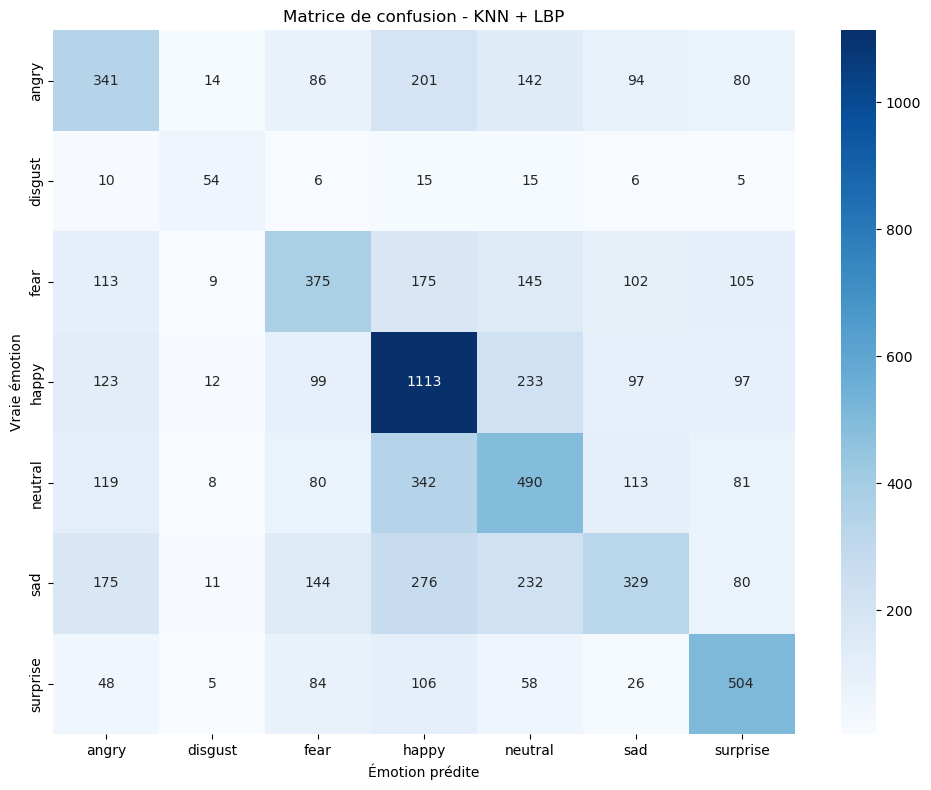

In [12]:
# La matrice de confusion montre pour chaque émotion
# combien de fois le modèle s'est trompé et avec quelle émotion
plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, 
            annot=True,        # afficher les nombres dans les cases
            fmt='d',           # format entier
            cmap='Blues',      # couleur bleue
            xticklabels=EMOTIONS, 
            yticklabels=EMOTIONS)

plt.title('Matrice de confusion - KNN + LBP')
plt.ylabel('Vraie émotion')
plt.xlabel('Émotion prédite')
plt.tight_layout()
plt.show()

## 8. Visualisation des prédictions

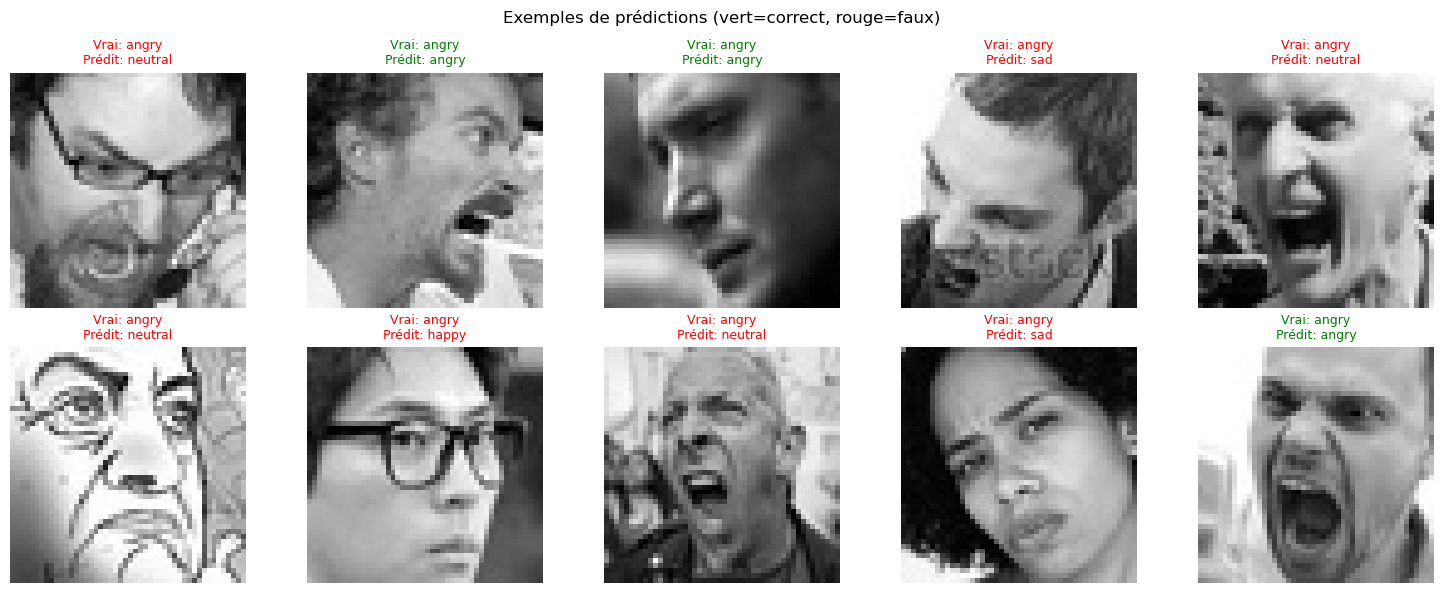

In [13]:
# Afficher 10 images avec leur vraie émotion et la prédiction du modèle
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # afficher l'image
    axes[i].imshow(X_test[i], cmap='gray')
    
    # vraie émotion et prédiction
    true_label = EMOTIONS[y_test[i]]
    pred_label = EMOTIONS[y_pred[i]]
    
    # titre vert si correct, rouge si faux
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'Vrai: {true_label}\nPrédit: {pred_label}', 
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Exemples de prédictions (vert=correct, rouge=faux)')
plt.tight_layout()
plt.show()

## 9. Conclusion
- Accuracy obtenue : **44.66%**
- Les émotions les mieux reconnues sont **happy** et **surprise**
- Les émotions les plus difficiles sont **sad** et **fear**
- Cette performance est limitée car KNN+LBP est une approche 
  classique. Des méthodes deep learning comme les CNN atteignent 
  66%+ sur le même dataset.